<a href="https://colab.research.google.com/github/Xavees/Fake-Real-Logo-Detection-Dataset/blob/main/projetoManita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"agustina4cevedo","key":"681fadbe053651fad832e427d78fc396"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d prosperchuks/fakereal-logo-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/prosperchuks/fakereal-logo-detection-dataset
License(s): CC0-1.0
100% 2.12M/2.12M [00:00<00:00, 171MB/s]



In [ ]:
!unzip fakereal-logo-detection-dataset.zip -d logos_dataset

Archive:  fakereal-logo-detection-dataset.zip
  inflating: logos_dataset/Logos.txt  
  inflating: logos_dataset/file_mapping.csv  
  inflating: logos_dataset/genLogoOutput/Adidas/000001.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/000002.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/000003.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/000004.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/000005.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/scal_000001.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/scal_000002.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/scal_000003.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/scal_000004.jpg  
  inflating: logos_dataset/genLogoOutput/Adidas/scal_000005.jpg  
  inflating: logos_dataset/genLogoOutput/Amazon/000001.jpg  
  inflating: logos_dataset/genLogoOutput/Amazon/000002.jpg  
  inflating: logos_dataset/genLogoOutput/Amazon/000003.jpg  
  inflating: logos_dataset/genLogoOutput/Amazon/000

In [ ]:
import os

for root, dirs, files in os.walk("logos_dataset"):
    print(root, len(files))

logos_dataset 2
logos_dataset/genLogoOutput 0
logos_dataset/genLogoOutput/Mtn 8
logos_dataset/genLogoOutput/Netflix 8
logos_dataset/genLogoOutput/PlayStation 10
logos_dataset/genLogoOutput/Amazon 10
logos_dataset/genLogoOutput/YouTube 10
logos_dataset/genLogoOutput/Guinness 10
logos_dataset/genLogoOutput/Adidas 10
logos_dataset/genLogoOutput/Cadbury 8
logos_dataset/genLogoOutput/Lays 10
logos_dataset/genLogoOutput/Lipton 8
logos_dataset/genLogoOutput/Apple 10
logos_dataset/genLogoOutput/BMW 8
logos_dataset/genLogoOutput/Peak milk 10
logos_dataset/genLogoOutput/Goya oil 6
logos_dataset/genLogoOutput/Tesla 10
logos_dataset/genLogoOutput/Oreo 6
logos_dataset/genLogoOutput/Fila 10
logos_dataset/genLogoOutput/Levis 8
logos_dataset/genLogoOutput/McDonald 10
logos_dataset/genLogoOutput/Nike 8
logos_dataset/genLogoOutput/Gillette 10
logos_dataset/genLogoOutput/Mars 6
logos_dataset/genLogoOutput/Nutella 8
logos_dataset/genLogoOutput/Zara 8
logos_dataset/genLogoOutput/Puma 6
logos_dataset/genLog

In [ ]:
import os

print(os.listdir("logos_dataset"))

['Logos.txt', 'file_mapping.csv', 'genLogoOutput', 'output']


In [ ]:
for item in os.listdir("logos_dataset"):
    caminho = os.path.join("logos_dataset", item)
    if os.path.isdir(caminho):
        print(item, "=>", os.listdir(caminho)[:10])

genLogoOutput => ['Mtn', 'Netflix', 'PlayStation', 'Amazon', 'YouTube', 'Guinness', 'Adidas', 'Cadbury', 'Lays', 'Lipton']
output => ['Mtn', 'Netflix', 'PlayStation', 'Amazon', 'YouTube', 'Guinness', 'Adidas', 'Cadbury', 'Lays', 'Lipton']


In [ ]:
import os

for pasta_principal in ["genLogoOutput", "output"]:
    caminho_principal = os.path.join("logos_dataset", pasta_principal)
    total = 0

    print(f"\nPasta: {pasta_principal}")

    for marca in os.listdir(caminho_principal)[:10]:
        caminho_marca = os.path.join(caminho_principal, marca)

        if os.path.isdir(caminho_marca):
            qtd = len(os.listdir(caminho_marca))
            total += qtd
            print(f"{marca}: {qtd} imagens")

    print("Total parcial mostrado:", total)


Pasta: genLogoOutput
Mtn: 8 imagens
Netflix: 8 imagens
PlayStation: 10 imagens
Amazon: 10 imagens
YouTube: 10 imagens
Guinness: 10 imagens
Adidas: 10 imagens
Cadbury: 8 imagens
Lays: 10 imagens
Lipton: 8 imagens
Total parcial mostrado: 92

Pasta: output
Mtn: 4 imagens
Netflix: 4 imagens
PlayStation: 5 imagens
Amazon: 5 imagens
YouTube: 5 imagens
Guinness: 5 imagens
Adidas: 5 imagens
Cadbury: 4 imagens
Lays: 5 imagens
Lipton: 4 imagens
Total parcial mostrado: 46


In [ ]:
import os

for pasta_principal in ["genLogoOutput", "output"]:
    caminho_principal = os.path.join("logos_dataset", pasta_principal)
    total = 0

    for marca in os.listdir(caminho_principal):
        caminho_marca = os.path.join(caminho_principal, marca)

        if os.path.isdir(caminho_marca):
            total += len(os.listdir(caminho_marca))

    print(pasta_principal, "=>", total, "imagens")

genLogoOutput => 550 imagens
output => 275 imagens


In [ ]:
import os
import shutil

# Pastas originais
pasta_fake_origem = "logos_dataset/genLogoOutput"
pasta_real_origem = "logos_dataset/output"

# Pasta final organizada
pasta_final = "dataset_final"
pasta_fake_destino = os.path.join(pasta_final, "fake")
pasta_real_destino = os.path.join(pasta_final, "real")

# Criar pastas finais
os.makedirs(pasta_fake_destino, exist_ok=True)
os.makedirs(pasta_real_destino, exist_ok=True)

def copiar_imagens(origem, destino, rotulo):
    contador = 0

    for marca in os.listdir(origem):
        caminho_marca = os.path.join(origem, marca)

        if os.path.isdir(caminho_marca):
            for arquivo in os.listdir(caminho_marca):
                caminho_arquivo = os.path.join(caminho_marca, arquivo)

                if os.path.isfile(caminho_arquivo):
                    extensao = os.path.splitext(arquivo)[1]
                    novo_nome = f"{rotulo}_{marca}_{contador}{extensao}"
                    caminho_destino = os.path.join(destino, novo_nome)

                    shutil.copy(caminho_arquivo, caminho_destino)
                    contador += 1

    return contador

qtd_fake = copiar_imagens(pasta_fake_origem, pasta_fake_destino, "fake")
qtd_real = copiar_imagens(pasta_real_origem, pasta_real_destino, "real")

print("Imagens fake copiadas:", qtd_fake)
print("Imagens real copiadas:", qtd_real)

Imagens fake copiadas: 550
Imagens real copiadas: 275


In [ ]:
import os

print("Fake:", len(os.listdir("dataset_final/fake")))
print("Real:", len(os.listdir("dataset_final/real")))

Fake: 550
Real: 275


In [ ]:
import tensorflow as tf

img_size = (70, 70)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_final",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_final",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("Classes encontradas:", train_ds.class_names)

Found 825 files belonging to 2 classes.
Using 660 files for training.
Found 825 files belonging to 2 classes.
Using 165 files for validation.
Classes encontradas: ['fake', 'real']


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(70, 70, 3)),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 70, 70, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 68, 68, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,321 (3.42 MB)

 Trainable params: 896,321 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 292ms/step - accuracy: 0.6545 - loss: 0.6404 - val_accuracy: 0.7333 - val_loss: 0.5309
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.7076 - loss: 0.5157 - val_accuracy: 0.6727 - val_loss: 0.5065
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.7439 - loss: 0.4679 - val_accuracy: 0.8061 - val_loss: 0.4342
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 348ms/step - accuracy: 0.7864 - loss: 0.4034 - val_accuracy: 0.6727 - val_loss: 0.5245
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.8091 - loss: 0.3786 - val_accuracy: 0.6970 - val_loss: 0.5268
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.8424 - loss: 0.3448 - val_accuracy: 0.8485 - val_loss: 0.3480
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.8606 - loss: 0.3074 - val_accuracy: 0.8909 - val_loss: 0.2713
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 339ms/step - accuracy: 0.8803 - loss: 0.2877 - val_accuracy

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Loss de validação:", loss)
print("Acurácia de validação:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9030 - loss: 0.2476
Loss de validação: 0.2476077526807785
Acurácia de validação: 0.903030276298523


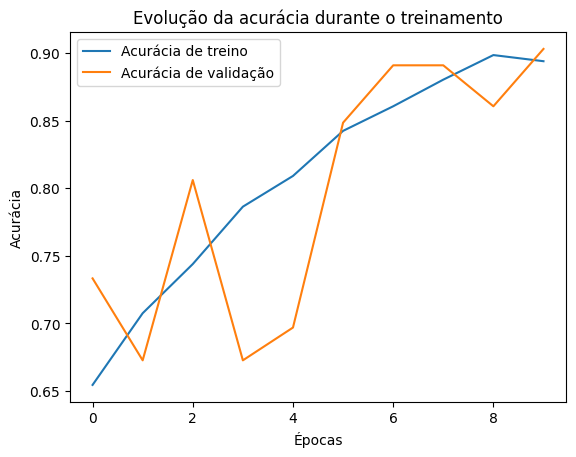

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Acurácia de treino")
plt.plot(history.history["val_accuracy"], label="Acurácia de validação")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Evolução da acurácia durante o treinamento")
plt.legend()
plt.show()

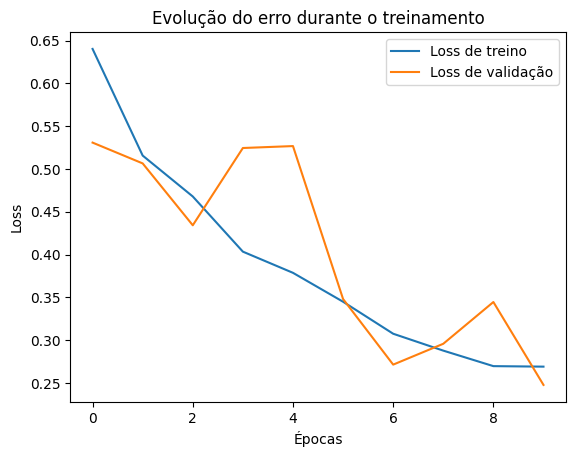

In [ ]:
plt.plot(history.history["loss"], label="Loss de treino")
plt.plot(history.history["val_loss"], label="Loss de validação")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolução do erro durante o treinamento")
plt.legend()
plt.show()

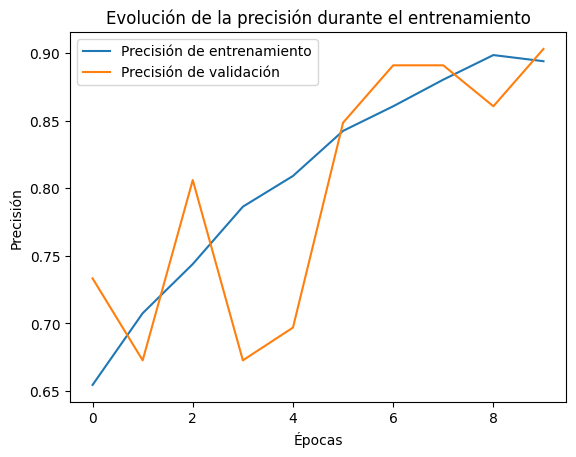

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Precisión de entrenamiento")
plt.plot(history.history["val_accuracy"], label="Precisión de validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.title("Evolución de la precisión durante el entrenamiento")
plt.legend()
plt.show()

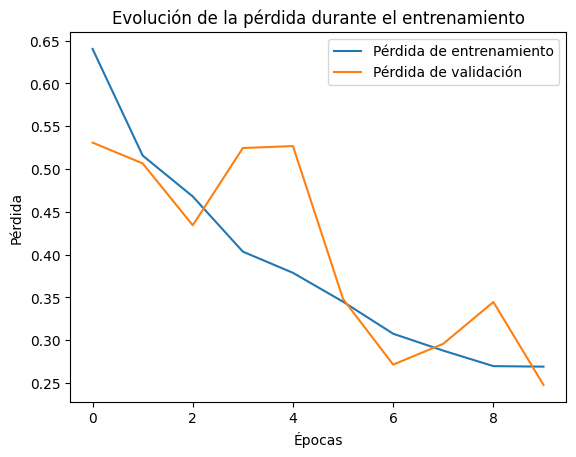

In [ ]:
plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


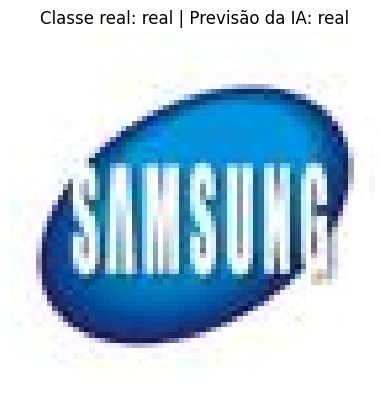

Arquivo: real_Samsung_245.jpg
Classe real: real
Probabilidade: 0.67183006
Previsão da IA: real


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Escolher uma imagem aleatória da pasta real ou fake
classe_teste = random.choice(["real", "fake"])
pasta_teste = f"dataset_final/{classe_teste}"

imagem_nome = random.choice(os.listdir(pasta_teste))
imagem_caminho = os.path.join(pasta_teste, imagem_nome)

# Carregar imagem
img = load_img(imagem_caminho, target_size=(70, 70))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Fazer previsão
pred = model.predict(img_array)[0][0]

# Interpretar resultado
classe_prevista = "real" if pred >= 0.5 else "fake"

# Mostrar imagem e resultado
plt.imshow(img)
plt.axis("off")
plt.title(f"Classe real: {classe_teste} | Previsão da IA: {classe_prevista}")
plt.show()

print("Arquivo:", imagem_nome)
print("Classe real:", classe_teste)
print("Probabilidade:", pred)
print("Previsão da IA:", classe_prevista)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


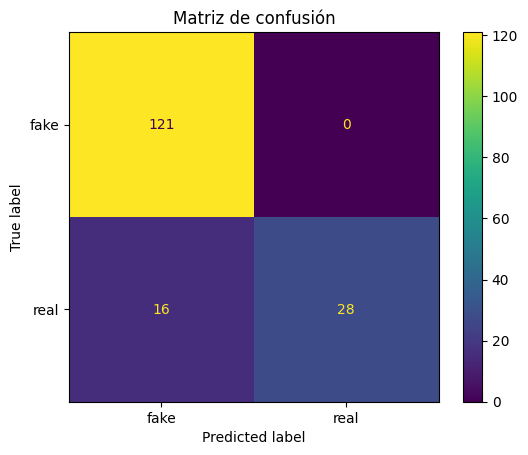

              precision    recall  f1-score   support

        fake       0.88      1.00      0.94       121
        real       1.00      0.64      0.78        44

    accuracy                           0.90       165
   macro avg       0.94      0.82      0.86       165
weighted avg       0.91      0.90      0.90       165



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["fake", "real"]
)

disp.plot()
plt.title("Matriz de confusión")
plt.show()

print(classification_report(y_true, y_pred, target_names=["fake", "real"]))

In [ ]:
model.save("modelo_logos_fake_real.keras")

In [ ]:
from google.colab import files
files.download("modelo_logos_fake_real.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving elisariva-social-2029117_1920.png to elisariva-social-2029117_1920.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


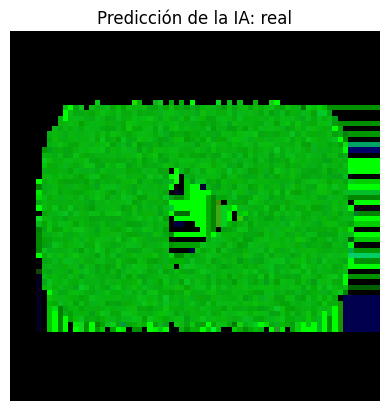

Archivo: elisariva-social-2029117_1920.png
Probabilidad: 0.9943578
Predicción: real


In [28]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    img = load_img(nome_arquivo, target_size=(70, 70))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]
    classe_prevista = "real" if pred >= 0.5 else "fake"

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción de la IA: {classe_prevista}")
    plt.show()

    print("Archivo:", nome_arquivo)
    print("Probabilidad:", pred)
    print("Predicción:", classe_prevista)

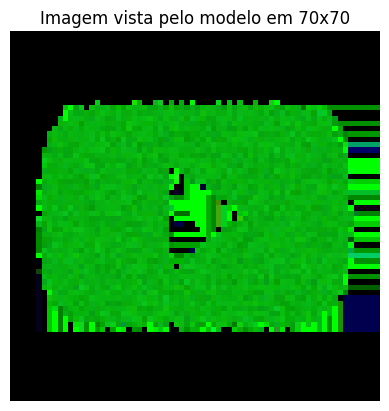

In [29]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

img = load_img("elisariva-social-2029117_1920.png", target_size=(70, 70))

plt.imshow(img)
plt.axis("off")
plt.title("Imagem vista pelo modelo em 70x70")
plt.show()

In [30]:
model.save("modelo_logos_fake_real.keras")

In [31]:
from google.colab import files
files.download("modelo_logos_fake_real.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import pandas as pd

historico = pd.DataFrame(history.history)
historico.to_csv("historico_treinamento.csv", index=False)

from google.colab import files
files.download("historico_treinamento.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>